## Setup

In [2]:
%load_ext autoreload
%autoreload 2

import torch
from experiments.utils.model_definitions.vision_automodel_wrapper import VisionLayerwiseAutoModelWrapper, VisionModelSpecifications
from experiments.utils.dataloaders.vision_dataloader import prepare_datasets, prepare_dataloader, validation_imagenet_transform, simclr_imagenet_transform
from experiments.utils.misc.results_saving import load_results, check_if_results_exist
from experiments.utils.metrics.metric_calling import EvaluationMetricSpecifications, calculate_and_save_layerwise_metrics
import tqdm
import numpy as np

## Make Model

In [34]:
model_specs = VisionModelSpecifications(model_family="dinov2", model_size="vitl14", revision="main")
model = VisionLayerwiseAutoModelWrapper(model_specs, device_map="auto", evaluation_layer_idx=11)

/home/AD/ofsk222/miniconda3/envs/information_plane/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at facebook/dinov2-base were not used when initializing Dinov2Model: ['encoder.layer.11.attention.attention.key.bias', 'encoder.layer.11.attention.attention.key.weight', 'encoder.layer.11.attention.attention.query.bias', 'encoder.layer.11.attention.attention.query.weight', 'encoder.layer.11.attention.attention.value.bias', 'encoder.layer.11.attention.attention.value.weight', 'encoder.layer.11.attention.output.dense.bias', 'encoder.layer.11.attention.output.dense.weight', 'encoder.layer.11.layer_scale1.lambda1', 'encoder.layer.11.layer_scale2.lambda1', 'encoder.layer.11.mlp.fc1.bias', 'encoder.layer.11.mlp.fc1.weight', 'encoder.laye

## Make Dataset

In [28]:
mean = model.image_processor.image_mean
std = model.image_processor.image_std

augmentation_transform = simclr_imagenet_transform(mean, std)
augmented_imagenet_dataset = prepare_datasets(
    dataset="imagenet", 
    transform=augmentation_transform,
    train_data_path="/home/AD/ofsk222/Research/exploration/information_plane/experiments/datasets"
)

validation_transform = validation_imagenet_transform(mean, std)
validation_imagenet_dataset = prepare_datasets(
    dataset="imagenet", 
    transform=validation_transform,
    train_data_path="/home/AD/ofsk222/Research/exploration/information_plane/experiments/datasets"
)


augmented_dataloader = prepare_dataloader(augmented_imagenet_dataset, batch_size=16, num_workers=4, shuffle=False)
validation_dataloader = prepare_dataloader(validation_imagenet_dataset, batch_size=16, num_workers=4, shuffle=False)


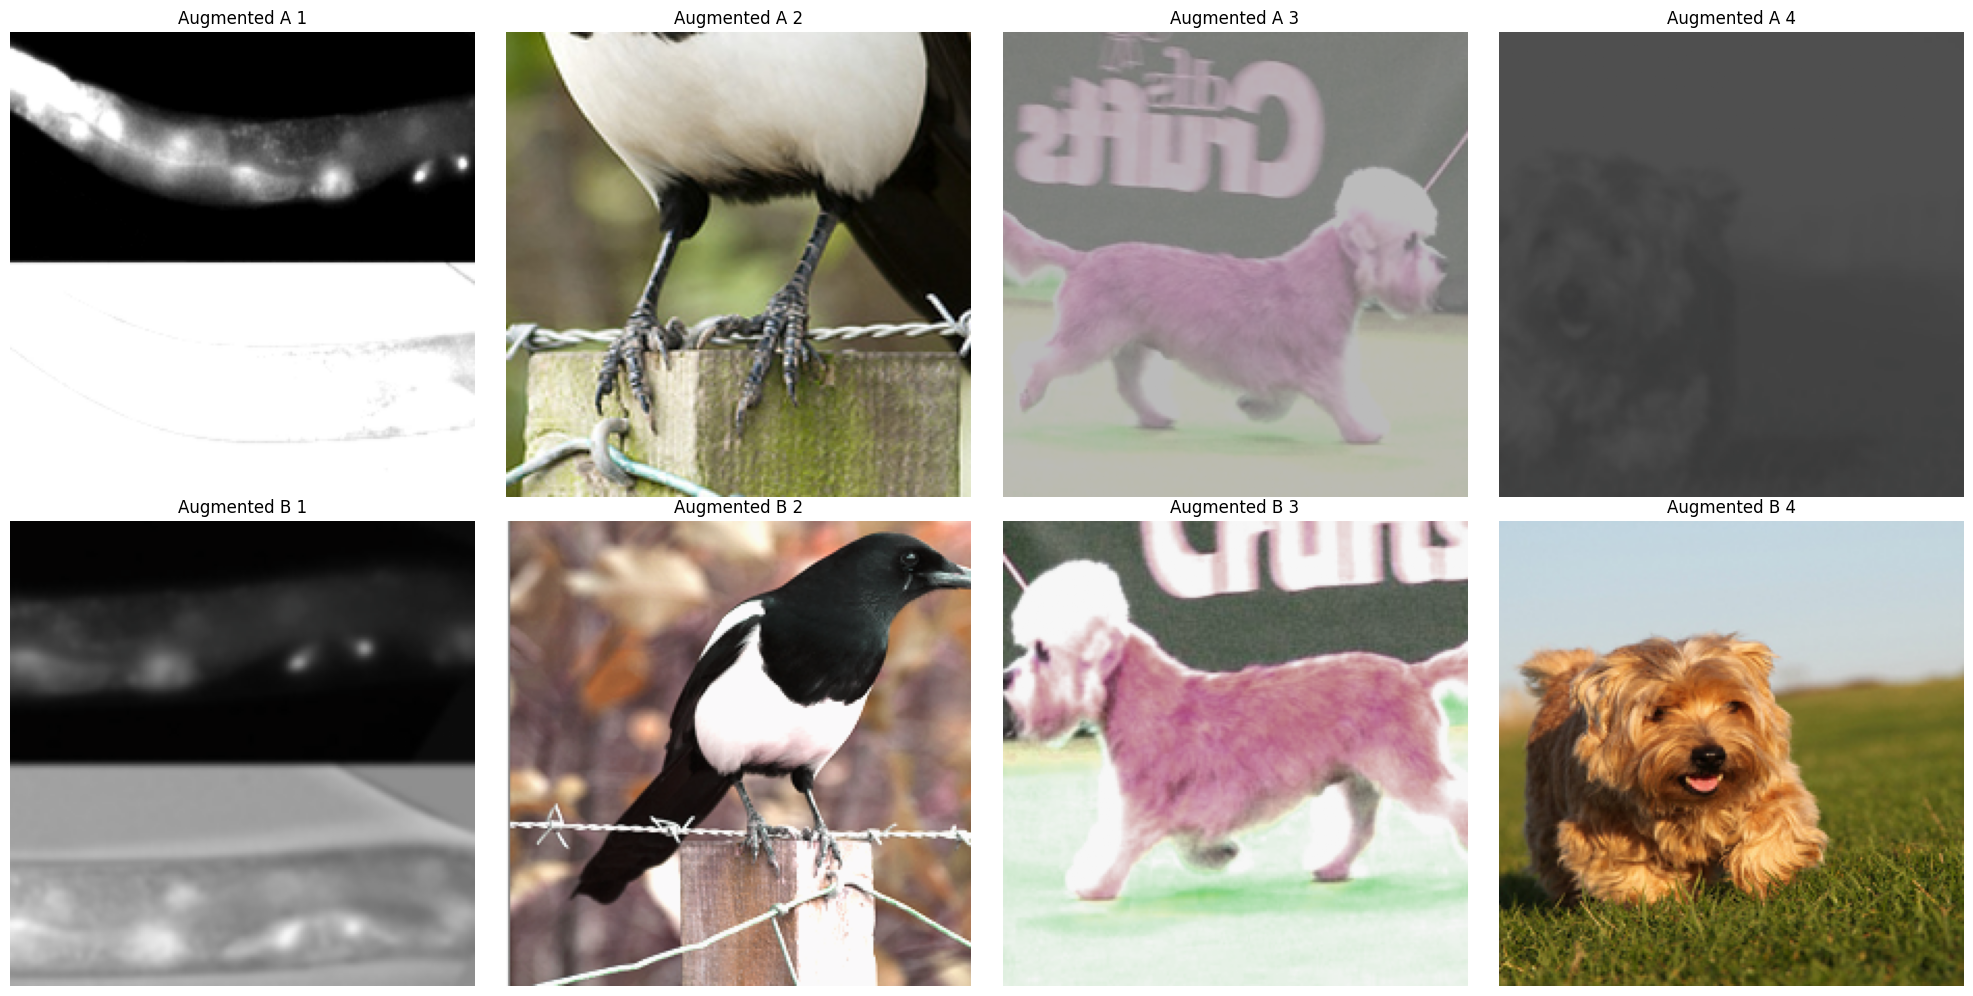

In [38]:
# show some images
import matplotlib.pyplot as plt

# Get a batch of data
dataiter = iter(augmented_dataloader)
batch_indices, images, targets = next(dataiter)

# Create a 2x4 grid of subplots
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Function to denormalize and convert tensor to image
def tensor_to_img(tensor):
    # Assuming the tensor is normalized with ImageNet stats
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = tensor * std + mean
    return img.permute(1, 2, 0).numpy()

# Display 4 pairs of images
for i in range(4):
    # Original image
    axes[0, i].imshow(tensor_to_img(images[0][i]))
    axes[0, i].axis('off')
    axes[0, i].set_title(f'Augmented A {i+1}')
    
    # Augmented image
    axes[1, i].imshow(tensor_to_img(images[1][i]))
    axes[1, i].axis('off')
    axes[1, i].set_title(f'Augmented B {i+1}')

plt.tight_layout()
plt.show()


In [47]:
# test the dataloader and model
sample_image = images[0][0]
inputs = {
    "pixel_values": sample_image.unsqueeze(0).to(model.dtype)
}

inputs = {k: v.to("cuda") for k, v in inputs.items()}

outputs = model.forward(**inputs)

for hidden_state in outputs["hidden_states"]:
    print(hidden_state.shape)

AttributeError: 'Dinov2PatchEmbeddings' object has no attribute 'config'

In [31]:
logits = outputs["logits"]
predicted_label = logits.argmax(-1).item()

print(model.config.id2label[predicted_label])

KeyError: 'logits'

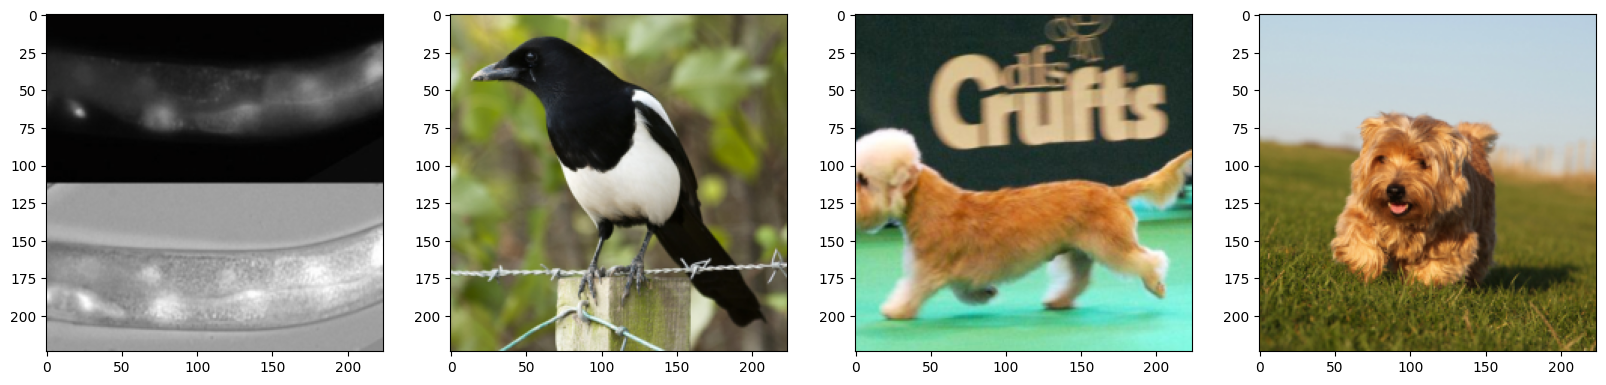

In [32]:
# show some validation images
dataiter = iter(validation_dataloader)
batch_indices, images, targets = next(dataiter)

fig, axes = plt.subplots(1, 4, figsize=(20, 10))

for i in range(4):
    axes[i].imshow(tensor_to_img(images[i]))

## Try many Models

In [3]:
models_to_try = [
    VisionModelSpecifications(model_family="dinov2", model_size="small", revision="main"),
    VisionModelSpecifications(model_family="dinov2", model_size="base", revision="main"),
    VisionModelSpecifications(model_family="dinov2", model_size="large", revision="main"),
    VisionModelSpecifications(model_family="dinov2", model_size="giant", revision="main"),
    # VisionModelSpecifications(model_family="dinov2-register", model_size="small", revision="main"),
    # VisionModelSpecifications(model_family="dinov2-register", model_size="base", revision="main"),
    # VisionModelSpecifications(model_family="dinov2-register", model_size="large", revision="main"),
    # VisionModelSpecifications(model_family="dinov2-register", model_size="giant", revision="main"),
    VisionModelSpecifications(model_family="i-jepa", model_size="imagenet1k", revision="main"),
    VisionModelSpecifications(model_family="i-jepa", model_size="imagenet21k", revision="main"),
    VisionModelSpecifications(model_family="mae", model_size="base", revision="main"),
    VisionModelSpecifications(model_family="mae", model_size="large", revision="main"),
    VisionModelSpecifications(model_family="mae", model_size="huge", revision="main"),
    VisionModelSpecifications(model_family="clip", model_size="base", revision="main"),
    VisionModelSpecifications(model_family="clip", model_size="large", revision="main"),
    VisionModelSpecifications(model_family="vit", model_size="base", revision="main"),
    VisionModelSpecifications(model_family="vit", model_size="large", revision="main"),
    VisionModelSpecifications(model_family="vit", model_size="huge", revision="main"),

]   

model_to_results = {}
for model_specs in models_to_try:
    print(model_specs)
    
    key = f"{model_specs.model_family}-{model_specs.model_size}"
    evaluation_metric_specs = EvaluationMetricSpecifications(evaluation_metric="sentence-entropy")
    dataloader_kwargs = {"dataset_name": "imagenet"}

    if check_if_results_exist(model_specs, evaluation_metric_specs, dataloader_kwargs):
        model_to_results[key] = load_results(model_specs, evaluation_metric_specs, dataloader_kwargs)
        continue

    model = VisionLayerwiseAutoModelWrapper(model_specs, device_map="auto")

    validation_imagenet_dataset = prepare_datasets(
        dataset="imagenet", 
        transform=model.process_inputs,
        train_data_path="/home/AD/ofsk222/Research/exploration/information_plane/experiments/datasets"
    )
    validation_dataloader = prepare_dataloader(validation_imagenet_dataset, batch_size=32, num_workers=32, shuffle=False)


    results = calculate_and_save_layerwise_metrics(model, validation_dataloader, model_specs, evaluation_metric_specs, dataloader_kwargs)

    del model
    torch.cuda.empty_cache()


        Model family: dinov2
        Model size: small
        Revision: main
        

        Model family: dinov2
        Model size: base
        Revision: main
        

        Model family: dinov2
        Model size: large
        Revision: main
        

        Model family: dinov2
        Model size: giant
        Revision: main
        

        Model family: i-jepa
        Model size: imagenet1k
        Revision: main
        

        Model family: i-jepa
        Model size: imagenet21k
        Revision: main
        

        Model family: mae
        Model size: base
        Revision: main
        

        Model family: mae
        Model size: large
        Revision: main
        

        Model family: mae
        Model size: huge
        Revision: main
        

        Model family: clip
        Model size: base
        Revision: main
        

        Model family: clip
        Model size: large
        Revision: main
        

        Model family: vit
        Mod

In [4]:
print(model.model.num_features)

NameError: name 'model' is not defined

# Plotting

(10016, 41)
(10016, 33)
(10016, 13)
(10016, 13)
(32,)
(32,)


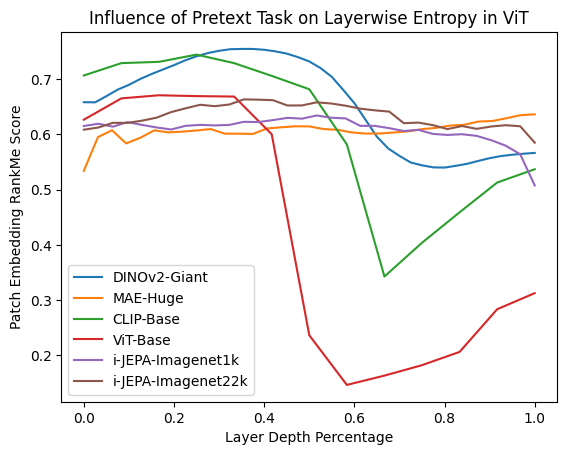

In [10]:
# plot mean entropy for each model

models_to_show = ['dinov2-giant', 'mae-huge', 'clip-base', 'vit-base', 'i-jepa-imagenet1k', 'i-jepa-imagenet21k']
model_to_labels = {
    'dinov2-giant': 'DINOv2-Giant',
    'mae-huge': 'MAE-Huge',
    'clip-base': 'CLIP-Base',
    'vit-base': 'ViT-Base',
    'i-jepa-imagenet1k': 'i-JEPA-Imagenet1k',
    'i-jepa-imagenet21k': 'i-JEPA-Imagenet22k',
}

from matplotlib import pyplot as plt
for model_name in models_to_show:
    results = model_to_results[model_name]
    entropies = results['maxEntropy']
    print(entropies.shape)

    if 'jepa' in model_name:
        mean_entropy = entropies
    else:
        mean_entropy = np.mean(entropies, axis=0)

    depth_percentage = np.arange(len(mean_entropy)) / (len(mean_entropy)-1)
    plt.plot(depth_percentage, mean_entropy, label=model_to_labels[model_name])

plt.title("Influence of Pretext Task on Layerwise Entropy in ViT")
plt.xlabel("Layer Depth Percentage")
plt.ylabel("Patch Embedding RankMe Score")
plt.legend()
plt.show()

1. Supervised compresses the most
2. Reconstruction behaves than supervised / contrastive SSL
3. Augmentations vs masking (!)
4. Momentum encoder vs non-momentum
5. Larger dataset increases entropy
6. Can't compress with masking (every pixel matters)

TODO:
- VICReg, Barlow Twins, SimCLR
- Look for more models with imagenet-22k
- Look at accuracies

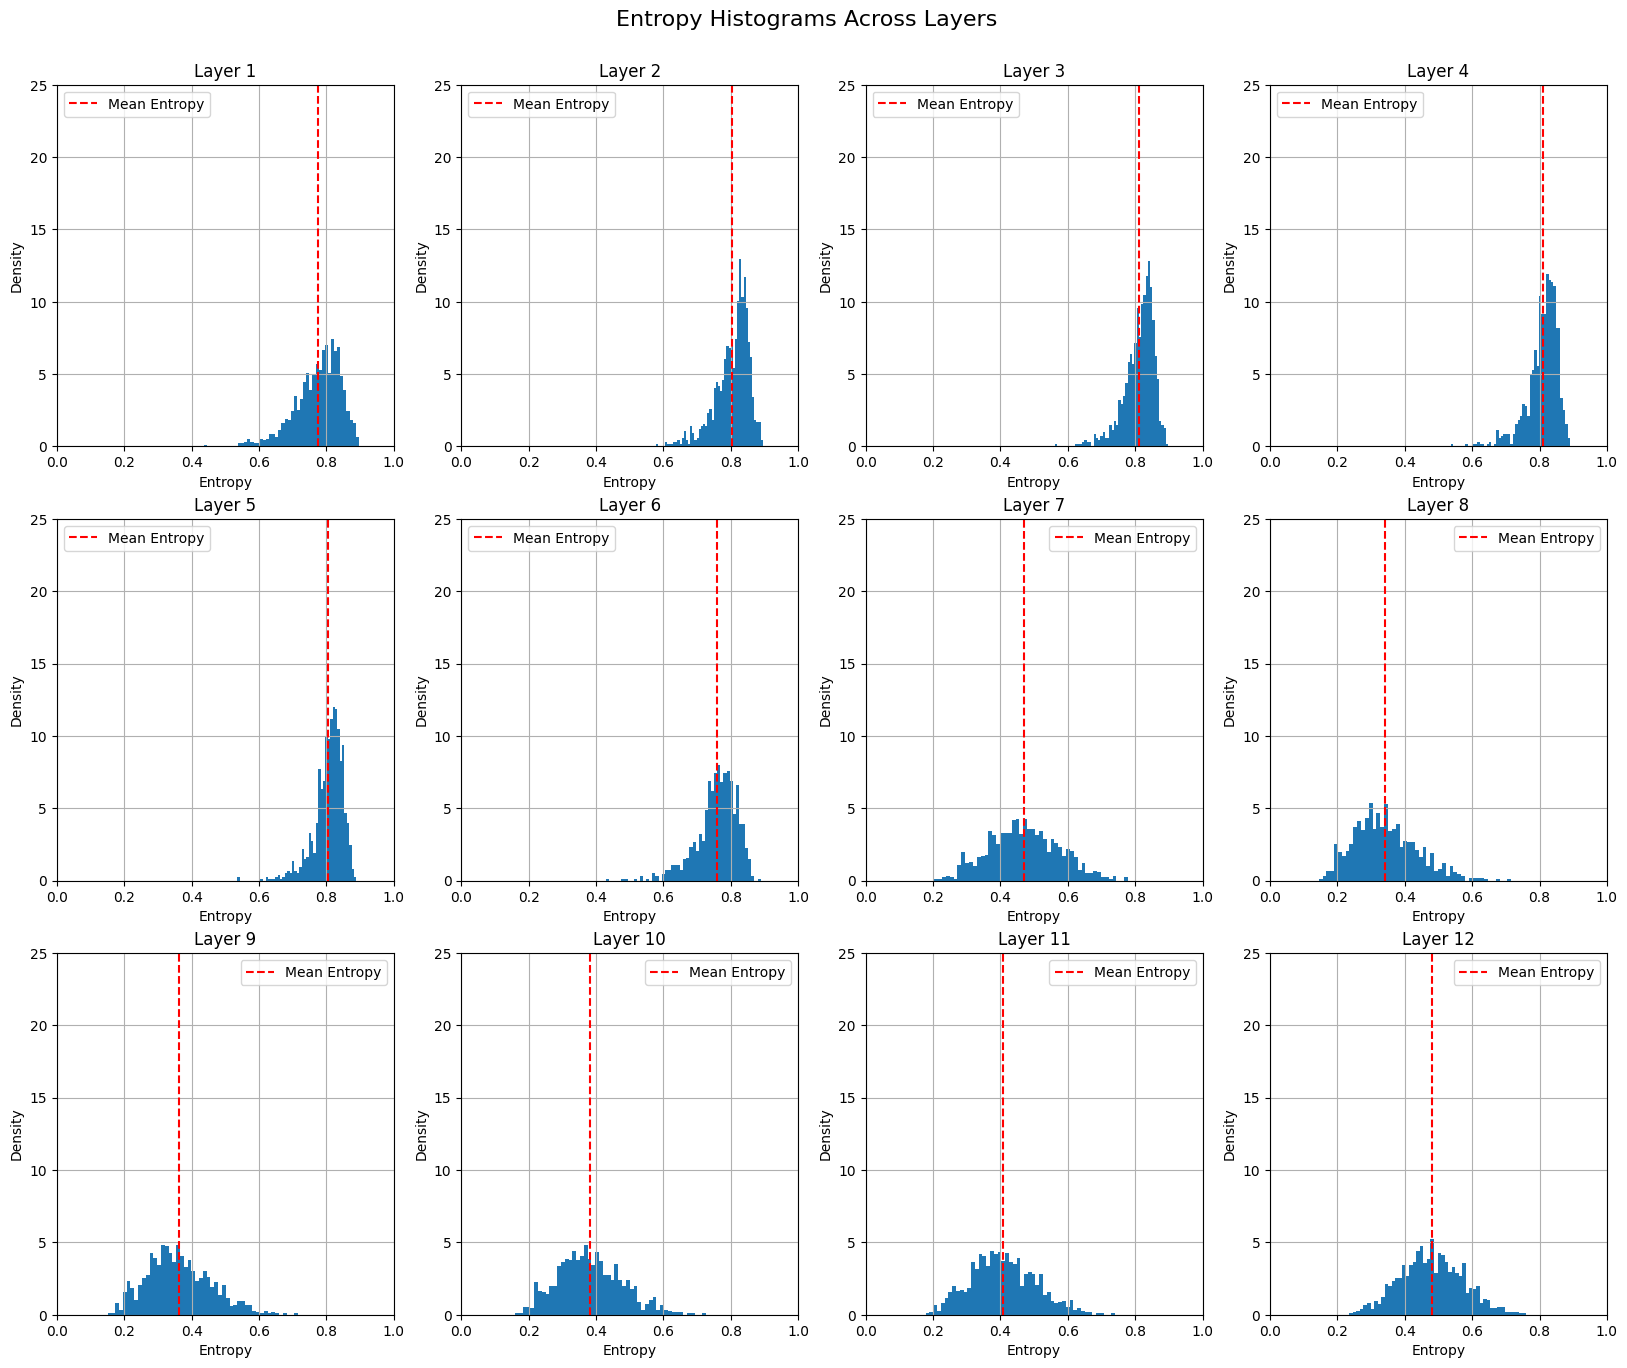

In [ ]:
trainset_entropies = model_to_results['vit']

# Create subplots to show entropy histograms across layers
num_layers = trainset_entropies['maxEntropy'].shape[1]
num_rows = (num_layers + 3) // 4  # Calculate number of rows, rounding up
fig, axes = plt.subplots(num_rows, 4, figsize=(20, 5 * num_rows), sharex=True)
axes = axes.flatten()

num_layers = trainset_entropies['maxEntropy'].shape[1]

for layer in range(num_layers):
    layer_entropies = trainset_entropies['maxEntropy'][:, layer]
    axes[layer].hist(layer_entropies, bins=50, density=True)
    axes[layer].set_title(f"Layer {layer+1}")
    axes[layer].set_ylabel("Density")
    
    axes[layer].set_xlabel("Entropy")
    axes[layer].grid(True)
    
    # Ensure x-axis ticks are visible for all subplots
    axes[layer].tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
    axes[layer].set_xlim(0, 1)
    axes[layer].set_ylim(0, 25)

    # plot mean line
    mean_entropy = np.mean(layer_entropies)
    axes[layer].axvline(mean_entropy, color='red', linestyle='--', label='Mean Entropy')
    axes[layer].legend()

# Remove extra subplots if any
for i in range(num_layers, len(axes)):
    fig.delaxes(axes[i])

plt.grid(True)

fig.suptitle("Entropy Histograms Across Layers", fontsize=16)
plt.subplots_adjust(top=0.93)
plt.show()